<a href="https://colab.research.google.com/github/saathvikMD/dqn/blob/main/cnn_pong.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import gym
import torch
import random
import matplotlib.pyplot as plt
import numpy as np
import os
os.environ.setdefault('PATH', '')
from collections import deque
import gym
from gym import spaces
import cv2
cv2.ocl.setUseOpenCL(False)
from gym.wrappers import TimeLimit


class NoopResetEnv(gym.Wrapper):
    def __init__(self, env, noop_max=30):

        gym.Wrapper.__init__(self, env)
        self.noop_max = noop_max
        self.override_num_noops = None
        self.noop_action = 0
        assert env.unwrapped.get_action_meanings()[0] == 'NOOP'

    def reset(self, **kwargs):
       
        self.env.reset(**kwargs)
        if self.override_num_noops is not None:
            noops = self.override_num_noops
        else:
            noops = self.unwrapped.np_random.randint(1, self.noop_max + 1) 
        assert noops > 0
        obs = None
        for _ in range(noops):
            obs, _, done, _ = self.env.step(self.noop_action)
            if done:
                obs = self.env.reset(**kwargs)
        return obs

    def step(self, ac):
        return self.env.step(ac)

class FireResetEnv(gym.Wrapper):
    def __init__(self, env):
     
        gym.Wrapper.__init__(self, env)
        assert env.unwrapped.get_action_meanings()[1] == 'FIRE'
        assert len(env.unwrapped.get_action_meanings()) >= 3

    def reset(self, **kwargs):
        self.env.reset(**kwargs)
        obs, _, done, _ = self.env.step(1)
        if done:
            self.env.reset(**kwargs)
        obs, _, done, _ = self.env.step(2)
        if done:
            self.env.reset(**kwargs)
        return obs

    def step(self, ac):
        return self.env.step(ac)

class EpisodicLifeEnv(gym.Wrapper):
    def __init__(self, env):

        gym.Wrapper.__init__(self, env)
        self.lives = 0
        self.was_real_done  = True

    def step(self, action):
        obs, reward, done, info = self.env.step(action)
        self.was_real_done = done

        lives = self.env.unwrapped.ale.lives()
        if lives < self.lives and lives > 0:

            done = True
        self.lives = lives
        return obs, reward, done, info

    def reset(self, **kwargs):
        """Reset only when lives are exhausted.
        This way all states are still reachable even though lives are episodic,
        and the learner need not know about any of this behind-the-scenes.
        """
        if self.was_real_done:
            obs = self.env.reset(**kwargs)
        else:

            obs, _, _, _ = self.env.step(0)
        self.lives = self.env.unwrapped.ale.lives()
        return obs

class MaxAndSkipEnv(gym.Wrapper):
    def __init__(self, env, skip=4):
        """Return only every `skip`-th frame"""
        gym.Wrapper.__init__(self, env)

        self._obs_buffer = np.zeros((2,)+env.observation_space.shape, dtype=np.uint8)
        self._skip       = skip

    def step(self, action):
        """Repeat action, sum reward, and max over last observations."""
        total_reward = 0.0
        done = None
        for i in range(self._skip):
            obs, reward, done, info = self.env.step(action)
            if i == self._skip - 2: self._obs_buffer[0] = obs
            if i == self._skip - 1: self._obs_buffer[1] = obs
            total_reward += reward
            if done:
                break

        max_frame = self._obs_buffer.max(axis=0)

        return max_frame, total_reward, done, info

    def reset(self, **kwargs):
        return self.env.reset(**kwargs)

class ClipRewardEnv(gym.RewardWrapper):
    def __init__(self, env):
        gym.RewardWrapper.__init__(self, env)

    def reward(self, reward):
        """Bin reward to {+1, 0, -1} by its sign."""
        return np.sign(reward)


class WarpFrame(gym.ObservationWrapper):
    def __init__(self, env, width=84, height=84, grayscale=True, dict_space_key=None):
        """
        Warp frames to 84x84 as done in the Nature paper and later work.

        If the environment uses dictionary observations, `dict_space_key` can be specified which indicates which
        observation should be warped.
        """
        super().__init__(env)
        self._width = width
        self._height = height
        self._grayscale = grayscale
        self._key = dict_space_key
        if self._grayscale:
            num_colors = 1
        else:
            num_colors = 3

        new_space = gym.spaces.Box(
            low=0,
            high=255,
            shape=(self._height, self._width, num_colors),
            dtype=np.uint8,
        )
        if self._key is None:
            original_space = self.observation_space
            self.observation_space = new_space
        else:
            original_space = self.observation_space.spaces[self._key]
            self.observation_space.spaces[self._key] = new_space
        assert original_space.dtype == np.uint8 and len(original_space.shape) == 3

    def observation(self, obs):
        if self._key is None:
            frame = obs
        else:
            frame = obs[self._key]

        if self._grayscale:
            frame = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
        frame = cv2.resize(
            frame, (self._width, self._height), interpolation=cv2.INTER_AREA
        )
        if self._grayscale:
            frame = np.expand_dims(frame, -1)

        if self._key is None:
            obs = frame
        else:
            obs = obs.copy()
            obs[self._key] = frame
        return obs


class FrameStack(gym.Wrapper):
    def __init__(self, env, k):
        """Stack k last frames.

        Returns lazy array, which is much more memory efficient.

        See Also
        --------
        baselines.common.atari_wrappers.LazyFrames
        """
        gym.Wrapper.__init__(self, env)
        self.k = k
        self.frames = deque([], maxlen=k)
        shp = env.observation_space.shape
        self.observation_space = spaces.Box(low=0, high=255, shape=(shp[:-1] + (shp[-1] * k,)), dtype=env.observation_space.dtype)

    def reset(self):
        ob = self.env.reset()
        for _ in range(self.k):
            self.frames.append(ob)
        return self._get_ob()

    def step(self, action):
        ob, reward, done, info = self.env.step(action)
        self.frames.append(ob)
        return self._get_ob(), reward, done, info

    def _get_ob(self):
        assert len(self.frames) == self.k
        return LazyFrames(list(self.frames))

class ScaledFloatFrame(gym.ObservationWrapper):
    def __init__(self, env):
        gym.ObservationWrapper.__init__(self, env)
        self.observation_space = gym.spaces.Box(low=0, high=1, shape=env.observation_space.shape, dtype=np.float32)

    def observation(self, observation):
        return np.array(observation).astype(np.float32) / 255.0

class LazyFrames(object):
    def __init__(self, frames):

        self._frames = frames
        self._out = None

    def _force(self):
        if self._out is None:
            self._out = np.concatenate(self._frames, axis=-1)
            self._frames = None
        return self._out

    def __array__(self, dtype=None):
        out = self._force()
        if dtype is not None:
            out = out.astype(dtype)
        return out

    def __len__(self):
        return len(self._force())

    def __getitem__(self, i):
        return self._force()[i]

    def count(self):
        frames = self._force()
        return frames.shape[frames.ndim - 1]

    def frame(self, i):
        return self._force()[..., i]

def make_atari(env_id, max_episode_steps=None):
    env = gym.make(env_id)
    assert 'NoFrameskip' in env.spec.id
    env = NoopResetEnv(env, noop_max=30)
    env = MaxAndSkipEnv(env, skip=4)
    if max_episode_steps is not None:
        env = TimeLimit(env, max_episode_steps=max_episode_steps)
    return env

def wrap_deepmind(env, episode_life=True, clip_rewards=True, frame_stack=False, scale=False):
    """Configure environment for DeepMind-style Atari.
    """
    if episode_life:
        env = EpisodicLifeEnv(env)
    if 'FIRE' in env.unwrapped.get_action_meanings():
        env = FireResetEnv(env)
    env = WarpFrame(env)
    if scale:
        env = ScaledFloatFrame(env)
    if clip_rewards:
        env = ClipRewardEnv(env)
    if frame_stack:
        env = FrameStack(env, 4)
    return env

In [ ]:
env = make_atari('PongNoFrameskip-v4')
env = wrap_deepmind(env)

Episode finished. Reward: -21 step
Episode finished. Reward: -21 step
Episode finished. Reward: -20 step
Episode finished. Reward: -21 step
Episode finished. Reward: -20 step
Average rerward -20.60
Average rerward last hunred -1.03


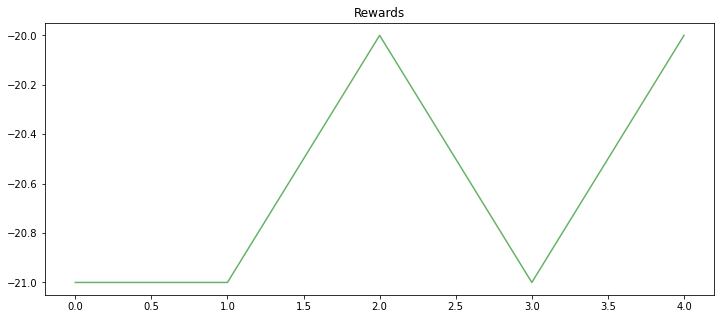

In [ ]:
seed_value = 23
env.seed(seed_value)
torch.manual_seed(seed_value)
random.seed(seed_value)

num_episodes = 5
rewards_total = []

for i in range(num_episodes):
  state = env.reset()
  score = 0
  while True:
    action = env.action_space.sample()

    new_state, reward, done, info = env.step(action)

    score += reward


    if done:
      rewards_total.append(score)
      print('Episode finished. Reward: %i step' % score)    
      break

print('Average rerward %.2f' %(sum(rewards_total)/num_episodes))
print('Average rerward last hunred %.2f' %(sum(rewards_total[-100:])/100))

plt.figure(figsize = (12,5))
plt.title('Rewards')
plt.plot(rewards_total, alpha = 0.6, color = 'green')
plt.show()

env.close()
env.env.close()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import gym
import random
import math
import time
import os.path

import matplotlib.pyplot as plt

plt.style.use('ggplot')

use_cuda = torch.cuda.is_available()

device = torch.device("cuda:0" if use_cuda else "cpu")
Tensor = torch.Tensor
LongTensor = torch.LongTensor

env_id = "PongNoFrameskip-v4"
env = make_atari(env_id)
env = wrap_deepmind(env)

directory = './PongVideos/'
env = gym.wrappers.Monitor(env, directory, video_callable=lambda episode_id: episode_id%20==0, force = True)


seed_value = 23
env.seed(seed_value)
torch.manual_seed(seed_value)
random.seed(seed_value)


learning_rate = 0.0001
num_episodes = 500
gamma = 0.99

hidden_layer = 512

replay_mem_size = 100000
batch_size = 32

update_target_frequency = 2000

double_dqn = True

egreedy = 0.9
egreedy_final = 0.01
egreedy_decay = 10000

report_interval = 10
score_to_solve = 600

clip_error = True
normalize_image = True

file2save = 'pong_save.pth'
save_model_frequency = 10
resume_previous_training = False



number_of_inputs = env.observation_space.shape[0]
number_of_outputs = env.action_space.n

def calculate_epsilon(steps_done):
    epsilon = egreedy_final + (egreedy - egreedy_final) * \
              math.exp(-1. * steps_done / egreedy_decay )
    return epsilon

def load_model():
    return torch.load(file2save)

def save_model(model):
    torch.save(model.state_dict(), file2save)
    
def preprocess_frame(frame):
    frame = frame.transpose((2,0,1))
    frame = torch.from_numpy(frame)
    frame = frame.to(device, dtype=torch.float32)
    frame = frame.unsqueeze(1)
    
    return frame

def plot_results():
    plt.figure(figsize=(12,5))
    plt.title("Rewards")
    plt.plot(rewards_total, alpha=0.6, color='red')
    plt.savefig("Pong-results.png")
    plt.close()

class ExperienceReplay(object):
    def __init__(self, capacity):
        self.capacity = capacity
        self.memory = []
        self.position = 0
 
    def push(self, state, action, new_state, reward, done):
        transition = (state, action, new_state, reward, done)
        
        if self.position >= len(self.memory):
            self.memory.append(transition)
        else:
            self.memory[self.position] = transition
        
        self.position = ( self.position + 1 ) % self.capacity
        
        
    def sample(self, batch_size):
        return zip(*random.sample(self.memory, batch_size))
        
        
    def __len__(self):
        return len(self.memory)
        
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1)
        
        self.advantage1 = nn.Linear(7*7*64,hidden_layer)
        self.advantage2 = nn.Linear(hidden_layer, number_of_outputs)
        
        self.value1 = nn.Linear(7*7*64,hidden_layer)
        self.value2 = nn.Linear(hidden_layer,1)

        self.activation = nn.ReLU()
        
        
    def forward(self, x):
        
        if normalize_image:
            x = x / 255
        
        output_conv = self.conv1(x)
        output_conv = self.activation(output_conv)
        output_conv = self.conv2(output_conv)
        output_conv = self.activation(output_conv)
        output_conv = self.conv3(output_conv)
        output_conv = self.activation(output_conv)
        
        output_conv = output_conv.view(output_conv.size(0), -1) 
        
        output_advantage = self.advantage1(output_conv)
        output_advantage = self.activation(output_advantage)
        output_advantage = self.advantage2(output_advantage)
        
        output_value = self.value1(output_conv)
        output_value = self.activation(output_value)
        output_value = self.value2(output_value)
        
        output_final = output_value + output_advantage - output_advantage.mean()

        return output_final
    
class QNet_Agent(object):
    def __init__(self):
        self.nn = NeuralNetwork().to(device)
        self.target_nn = NeuralNetwork().to(device)

        self.loss_func = nn.MSELoss()
        
        
        self.optimizer = optim.Adam(params=self.nn.parameters(), lr=learning_rate)
      
        
        self.number_of_frames = 0
        
        if resume_previous_training and os.path.exists(file2save):
            print("Loading previously saved model ... ")
            self.nn.load_state_dict(load_model())
        
    def select_action(self,state,epsilon):
        
        random_for_egreedy = torch.rand(1)[0]
        
        if random_for_egreedy > epsilon:      
            
            with torch.no_grad():
                
                state = preprocess_frame(state)
                action_from_nn = self.nn(state)
                
                action = torch.max(action_from_nn,1)[1]
                action = action.item()        
        else:
            action = env.action_space.sample()
        
        return action
    
    def optimize(self):
        
        if (len(memory) < batch_size):
            return
        
        state, action, new_state, reward, done = memory.sample(batch_size)
        
        state = [ preprocess_frame(frame) for frame in state ] 
        state = torch.cat(state)
        
        new_state = [ preprocess_frame(frame) for frame in new_state ] 
        new_state = torch.cat(new_state)

        reward = Tensor(reward).to(device)
        action = LongTensor(action).to(device)
        done = Tensor(done).to(device)


        if double_dqn:
            new_state_indexes = self.nn(new_state).detach()
            max_new_state_indexes = torch.max(new_state_indexes, 1)[1]  
            
            new_state_values = self.target_nn(new_state).detach()
            max_new_state_values = new_state_values.gather(1, max_new_state_indexes.unsqueeze(1)).squeeze(1)
        else:
            new_state_values = self.target_nn(new_state).detach()
            max_new_state_values = torch.max(new_state_values, 1)[0]
        
        
        target_value = reward + ( 1 - done ) * gamma * max_new_state_values
  
        predicted_value = self.nn(state).gather(1, action.unsqueeze(1)).squeeze(1)
        
        loss = self.loss_func(predicted_value, target_value)
    
        self.optimizer.zero_grad()
        loss.backward()
        
        if clip_error:
            for param in self.nn.parameters():
                param.grad.data.clamp_(-1,1)
        
        self.optimizer.step()
        
        if self.number_of_frames % update_target_frequency == 0:
            self.target_nn.load_state_dict(self.nn.state_dict())
        
        if self.number_of_frames % save_model_frequency == 0:
            save_model(self.nn)
        
        self.number_of_frames += 1
        
        
        

memory = ExperienceReplay(replay_mem_size)
qnet_agent = QNet_Agent()

rewards_total = []

frames_total = 0 
solved_after = 0
solved = False

start_time = time.time()

for i_episode in range(num_episodes):
    
    state = env.reset()
    
    score = 0
    print(str(i_episode + 1))
    while True:
        
        frames_total += 1
        
        epsilon = calculate_epsilon(frames_total)
        
     
        action = qnet_agent.select_action(state, epsilon)
        
        new_state, reward, done, info = env.step(action)
        
        score += reward

        memory.push(state, action, new_state, reward, done)
        qnet_agent.optimize()
        
        state = new_state
        
        if done:
            rewards_total.append(score)
            
            mean_reward_100 = sum(rewards_total[-100:])/100
            
            if (mean_reward_100 > score_to_solve and solved == False):
                print("SOLVED! After %i episodes " % i_episode)
                solved_after = i_episode
                solved = True
            
            if (i_episode % report_interval == 0 and i_episode > 0):
                
                plot_results()
                
                print("\n*** Episode %i *** \
                      \nAv.reward: [last %i]: %.2f, [last 100]: %.2f, [all]: %.2f \
                      \nepsilon: %.2f, frames_total: %i" 
                  % 
                  ( i_episode,
                    report_interval,
                    sum(rewards_total[-report_interval:])/report_interval,
                    mean_reward_100,
                    sum(rewards_total)/len(rewards_total),
                    epsilon,
                    frames_total
                          ) 
                  )
                  
                elapsed_time = time.time() - start_time
                print("Elapsed time: ", time.strftime("%H:%M:%S", time.gmtime(elapsed_time)))



            break
        

print("\n\n\n\nAverage reward: %.2f" % (sum(rewards_total)/num_episodes))
print("Average reward (last 100 episodes): %.2f" % (sum(rewards_total[-100:])/100))
if solved:
    print("Solved after %i episodes" % solved_after)